# 05 — Modern Image Generators: StyleGAN, DALL-E, Stable Diffusion

## 📚 Learning Objectives

By completing this notebook, you will:
- **Describe how each of the three landmark systems works** — StyleGAN (GAN family), DALL-E (autoregressive/diffusion family), Stable Diffusion (latent diffusion) — and connect each to the architecture you already built in this course
- **Compare** the three across control, quality, openness, and hardware needs
- Re-run the **foundational GAN** all of them trace back to, as a hands-on anchor

*Honest scope note:* running the real systems requires GPUs and multi-GB model downloads, so this classroom notebook does not execute them. What runs here is the GAN foundation; the survey connects it to the production systems, and the references + Colab guide show the way to try the real ones.

## 🔗 Where this fits

**Builds on:** Course 10 — Unit 1 (GAN, StyleGAN) and Unit 3, lessons 01-04 (VAE, diffusion) — the production systems surveyed here are assembled from exactly those parts.

**Used later in:** Course 10 — Unit 4, which asks what these systems make possible and what that costs.

---

This notebook covers practical activities from **Course 10, Unit 3**:
- Understanding how AI images are generated by StyleGAN, DALL-E, and Stable Diffusion

---

## 🌍 Why this lesson exists — openness cuts both ways

In February 2023 Getty Images sued Stability AI in the United States, and separately in the UK High Court, alleging that Stability copied millions of Getty photographs to train Stable Diffusion. Part of Getty's evidence was straightforward: the **Getty watermark appearing in generated outputs**.

Hold both halves of that at once. Open weights are the reason you can run Stable Diffusion in a classroom, fine-tune it with LoRA, and control it with ControlNet — none of which is possible with DALL·E. Open *training-data practice* is what put it in court. The "openness" row of the comparison table below is not a footnote; it is usually the row that decides the project.

**What goes wrong without this:** a student who can name the mechanism but not the access model, licence and provenance cannot make a build-or-buy recommendation. In a procurement meeting, "it uses cross-attention on CLIP embeddings" answers no question anyone asked.


## The Three Systems, Mapped to What You Built

**StyleGAN (NVIDIA, 2019–)** — the GAN family's peak. Your unit-1 GAN (example 05) + the mapping network / style injection / truncation ideas from unit-1 example 07, scaled to 1024×1024 faces. Strengths: unmatched sharpness on narrow domains (faces), fine-grained *style* control. Weaknesses: per-domain training, no text control.

**DALL-E (OpenAI, 2021–)** — text-to-image. DALL-E 1 generated image *tokens* autoregressively (the unit-2 mechanism, pointed at pixels); DALL-E 2/3 switched to **diffusion** guided by text embeddings — the exact mechanism of example 04 plus text conditioning. Strengths: open-ended prompts. Weaknesses: closed model, API-only.

**Stable Diffusion (Stability AI/LMU, 2022–)** — open-source **latent diffusion**: example 04's DDPM run inside example 01's VAE latent space, steered by CLIP text embeddings through cross-attention. Strengths: open weights, runs on consumer GPUs, huge ecosystem (LoRA fine-tunes, ControlNet). Weaknesses: quality depends on prompt/negative-prompt craft.


                                                    StyleGAN                      DALL-E 2/3                Stable Diffusion
core mechanism                             GAN (adversarial)                diffusion + text         latent diffusion + text
control signal                   none (unconditional/domain)                     text prompt  text prompt (+ControlNet etc.)
output domain                     narrow domain, ultra-sharp               open-ended scenes               open-ended scenes
openness                                        open weights               closed (API only)                    open weights
hardware               GPU for training, modest for sampling                      cloud only            consumer GPU (~8 GB)
you built the core in                 unit 1, examples 05+07  example 04 + text conditioning   examples 01 (VAE) + 04 (DDPM)


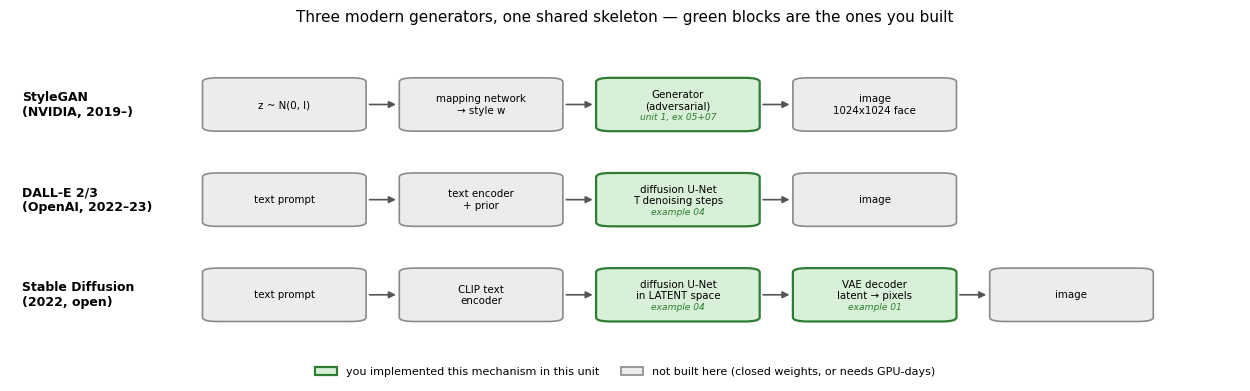

In [1]:
# WHAT/WHY: two views of the same three systems. First a printed comparison
# table (the reference summary, from the cited papers/docs). Then a diagram of
# the PIPELINES, because the table lists attributes and the survey's real claim
# is structural: all three are the same skeleton with different front ends, and
# the blocks drawn in green are mechanisms you implemented in this unit.
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Patch

comparison = pd.DataFrame({
    "StyleGAN":         ["GAN (adversarial)", "none (unconditional/domain)", "narrow domain, ultra-sharp",
                         "open weights", "GPU for training, modest for sampling", "unit 1, examples 05+07"],
    "DALL-E 2/3":       ["diffusion + text", "text prompt", "open-ended scenes",
                         "closed (API only)", "cloud only", "example 04 + text conditioning"],
    "Stable Diffusion": ["latent diffusion + text", "text prompt (+ControlNet etc.)", "open-ended scenes",
                         "open weights", "consumer GPU (~8 GB)", "examples 01 (VAE) + 04 (DDPM)"],
}, index=["core mechanism", "control signal", "output domain",
          "openness", "hardware", "you built the core in"])

with pd.option_context("display.max_colwidth", 40, "display.width", 150):
    print(comparison.to_string())


# ── The same three systems as pipelines (schematic, not to scale) ─────────
BUILT = dict(fc="#d7f0d7", ec="#2e7d32", lw=1.6)   # mechanism built in this unit
NOT_B = dict(fc="#ececec", ec="#8a8a8a", lw=1.2)   # not built here

lanes = [
    ("StyleGAN\n(NVIDIA, 2019–)", [
        ("z ~ N(0, I)",                     None,             False),
        ("mapping network\n→ style w",      None,             False),
        ("Generator\n(adversarial)",        "unit 1, ex 05+07", True),
        ("image\n1024x1024 face",           None,             False)]),
    ("DALL-E 2/3\n(OpenAI, 2022–23)", [
        ("text prompt",                      None,             False),
        ("text encoder\n+ prior",           None,             False),
        ("diffusion U-Net\nT denoising steps", "example 04",   True),
        ("image",                            None,             False)]),
    ("Stable Diffusion\n(2022, open)", [
        ("text prompt",                      None,             False),
        ("CLIP text\nencoder",              None,             False),
        ("diffusion U-Net\nin LATENT space", "example 04",     True),
        ("VAE decoder\nlatent → pixels",     "example 01",     True),
        ("image",                            None,             False)]),
]

fig, ax = plt.subplots(figsize=(12.6, 4.0))
ax.set_xlim(0, 100); ax.set_ylim(0, 100); ax.axis('off')
BW, GAP, X0, BH = 12.6, 3.4, 16.0, 15
for (title, blocks), y in zip(lanes, [78, 50, 22]):
    ax.text(1, y, title, fontsize=9, fontweight='bold', va='center', ha='left')
    for i, (label, note, built) in enumerate(blocks):
        x = X0 + i * (BW + GAP)
        ax.add_patch(FancyBboxPatch((x, y - BH / 2), BW, BH,
                                    boxstyle="round,pad=0.35,rounding_size=1.2",
                                    **(BUILT if built else NOT_B)))
        ax.text(x + BW / 2, y + (1.4 if note else 0), label, fontsize=7.4,
                ha='center', va='center')
        if note:                                  # which lesson built this block
            ax.text(x + BW / 2, y - 3.6, note, fontsize=6.6, ha='center',
                    va='center', color="#2e7d32", style='italic')
        if i < len(blocks) - 1:                   # arrow to the next block
            ax.annotate("", xy=(x + BW + GAP - 0.4, y), xytext=(x + BW + 0.4, y),
                        arrowprops=dict(arrowstyle='-|>', lw=1.2, color='#555'))
ax.legend(handles=[Patch(label="you implemented this mechanism in this unit", **BUILT),
                   Patch(label="not built here (closed weights, or needs GPU-days)", **NOT_B)],
          loc='lower center', bbox_to_anchor=(0.5, -0.05), ncol=2, fontsize=8, frameon=False)
ax.set_title("Three modern generators, one shared skeleton — green blocks are the ones you built",
             fontsize=11)
plt.tight_layout(); plt.show()

### 👁️ Read the diagram

**Every lane has the same skeleton:** a source of randomness or text on the left, a learned
generator in the middle, an image on the right. What separates the three systems is not the
generator's job but what feeds it and what comes out.

- **StyleGAN** takes *no text*. Its input is a noise vector, so you get "a face", not "this
  face" — control comes from editing the style vector w after the fact.
- **DALL-E 2/3** replaces the noise vector's role with a text embedding and swaps the
  adversarial generator for a diffusion U-Net. That U-Net is the mechanism you implemented in
  example 04; the text-conditioning path into it is the part you did not build.
- **Stable Diffusion** is the same diffusion U-Net moved *inside* a VAE latent space, so it has
  one extra block the other two do not: a **VAE decoder** to get back to pixels. That is the
  block from example 01, and it is the whole reason the system runs on a consumer GPU — the
  U-Net works on a 64×64×4 latent instead of a 512×512×3 image.

**The grey blocks are the honest part of this picture.** Text encoders, GPU-days of training
and 1024² resolution are not things this course reproduces. What the green blocks say is
narrower and true: the *mechanisms* in the middle of all three pipelines are the ones you have
already written, at classroom scale.

## 💬 Discuss

1. The "openness" row reads: open weights, closed API, open weights. For a Saudi government client with data-residency requirements, which row of this table decides the choice — and does the "core mechanism" row matter to that decision at all?
2. Our anchor GAN trains in minutes; StyleGAN needs GPU-days and Stable Diffusion needed a datacentre. What can you honestly claim to have learned about the large systems from the small one? Write the sentence you would defend, and the sentence you would not.
3. Getty's evidence included its own watermark appearing in generated images. What does that do to the argument that "the model only learns statistics, it does not store images"? (Compare Carlini et al., 2023, arXiv 2301.13188.)


## 🌍 Hands-On Anchor — the GAN They All Trace Back To

Everything above descends from the 2014 adversarial idea. As the runnable anchor for this survey, here is the small **fully-connected GAN** from unit 1 (a real DCGAN adds convolutions), generating digits from noise.


Epoch 2/8 — D loss: 0.453  G loss: 2.362


Epoch 4/8 — D loss: 0.538  G loss: 1.747


Epoch 6/8 — D loss: 0.436  G loss: 2.715


Epoch 8/8 — D loss: 0.477  G loss: 2.255


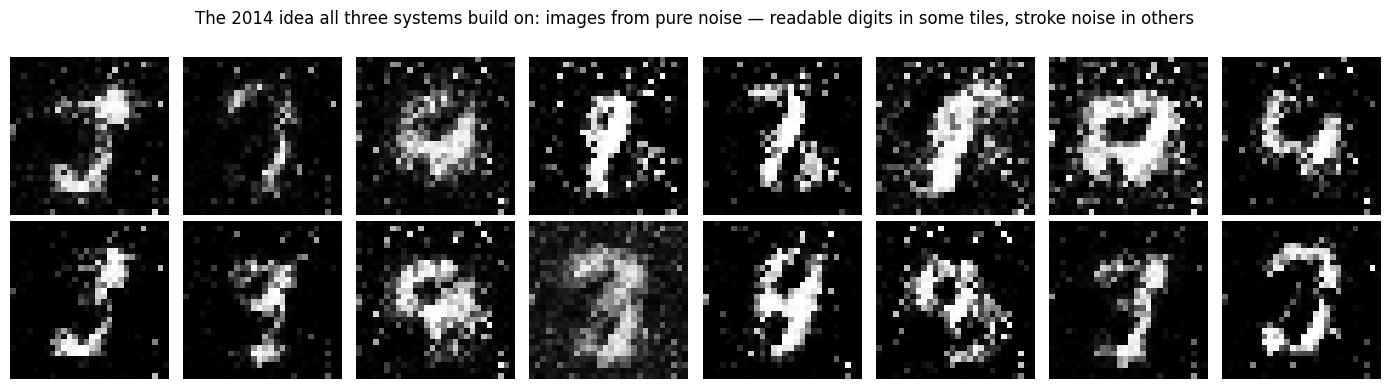

In [2]:
# WHAT/WHY: re-run the foundational GAN (unit 1, example 05) as this survey's
# hands-on anchor — adversarial training, then digits sampled from pure noise.
import torch, torch.nn as nn, torch.optim as optim
import torchvision, torchvision.transforms as T
import matplotlib.pyplot as plt

torch.manual_seed(42)
LATENT_DIM = 64; BATCH = 128

transform = T.Compose([T.ToTensor(), T.Normalize([0.5], [0.5])])
dataset   = torchvision.datasets.MNIST('/tmp/mnist', train=True, download=True, transform=transform)
subset    = torch.utils.data.Subset(dataset, range(25_600))
loader    = torch.utils.data.DataLoader(subset, batch_size=BATCH, shuffle=True)

# Generator: noise → image; Discriminator: image → real/fake probability
G = nn.Sequential(nn.Linear(LATENT_DIM, 256), nn.LeakyReLU(0.2),
                  nn.Linear(256, 512), nn.LeakyReLU(0.2),
                  nn.Linear(512, 28*28), nn.Tanh())
D = nn.Sequential(nn.Linear(28*28, 512), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                  nn.Linear(512, 256), nn.LeakyReLU(0.2), nn.Dropout(0.3),
                  nn.Linear(256, 1), nn.Sigmoid())
opt_G = optim.Adam(G.parameters(), lr=2e-4, betas=(0.5, 0.999))
opt_D = optim.Adam(D.parameters(), lr=2e-4, betas=(0.5, 0.999))
bce = nn.BCELoss()

# WHAT/WHY: record the epoch-average of both losses, and decode the SAME eight
# noise vectors after every epoch, so the next cell can show the adversarial
# game as a curve and the generator's progress as a storyboard. The fixed
# vectors come from a SEPARATE generator, so the global random stream — and
# every loss number printed below — is unchanged by adding the snapshots.
snap_gen  = torch.Generator().manual_seed(123)
fixed_z   = torch.randn(8, LATENT_DIM, generator=snap_gen)
gan_hist  = []      # (epoch, mean D loss, mean G loss)
snapshots = []      # those same eight vectors, generated after each epoch

EPOCHS = 8
for epoch in range(EPOCHS):
    d_sum = g_sum = 0.0
    for real_imgs, _ in loader:
        bs = real_imgs.size(0); real_flat = real_imgs.view(bs, -1)
        # D step: real → 1, detached fakes → 0
        fake = G(torch.randn(bs, LATENT_DIM)).detach()
        loss_D = bce(D(real_flat), torch.ones(bs, 1)) + bce(D(fake), torch.zeros(bs, 1))
        opt_D.zero_grad(); loss_D.backward(); opt_D.step()
        # G step: fool D
        fake = G(torch.randn(bs, LATENT_DIM))
        loss_G = bce(D(fake), torch.ones(bs, 1))
        opt_G.zero_grad(); loss_G.backward(); opt_G.step()
        d_sum += loss_D.item(); g_sum += loss_G.item()
    gan_hist.append((epoch + 1, d_sum / len(loader), g_sum / len(loader)))
    with torch.no_grad():                      # snapshots never touch gradients
        snapshots.append(G(fixed_z).view(-1, 28, 28).clone())
    if (epoch + 1) % 2 == 0:
        print(f"Epoch {epoch+1}/{EPOCHS} — D loss: {loss_D.item():.3f}  G loss: {loss_G.item():.3f}")

# ── Sample digits from pure noise, shown inline ───────────────────────────
G.eval()
with torch.no_grad():
    samples = G(torch.randn(16, LATENT_DIM)).view(16, 28, 28)
fig, axes = plt.subplots(2, 8, figsize=(14, 4))
for i, ax in enumerate(axes.flat):
    ax.imshow(samples[i], cmap='gray', vmin=-1, vmax=1); ax.axis('off')
plt.suptitle("The 2014 idea all three systems build on: images from pure noise — readable digits in some tiles, stroke noise in others")
plt.tight_layout(); plt.show()


## Watch the Game, Not Just the Final Grid

A GAN's loss numbers are famously hard to read: they measure how the two networks are doing
*against each other*, not how good the pictures are. So the next cell shows both — the two
losses over the whole run, and the same eight noise vectors generated after every epoch.

epoch   D loss   G loss
    1    1.116    0.889
    2    0.700    1.687
    3    0.661    2.232
    4    0.640    2.256
    5    0.649    2.431
    6    0.620    2.588
    7    0.699    2.312
    8    0.653    2.300


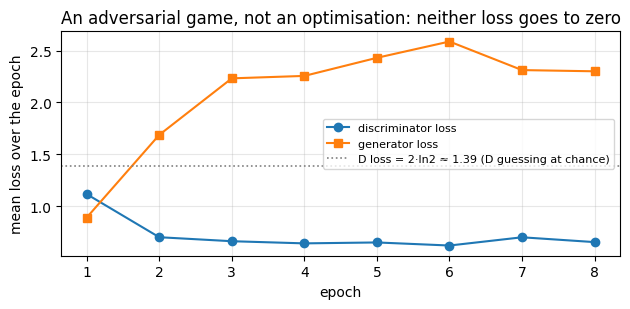

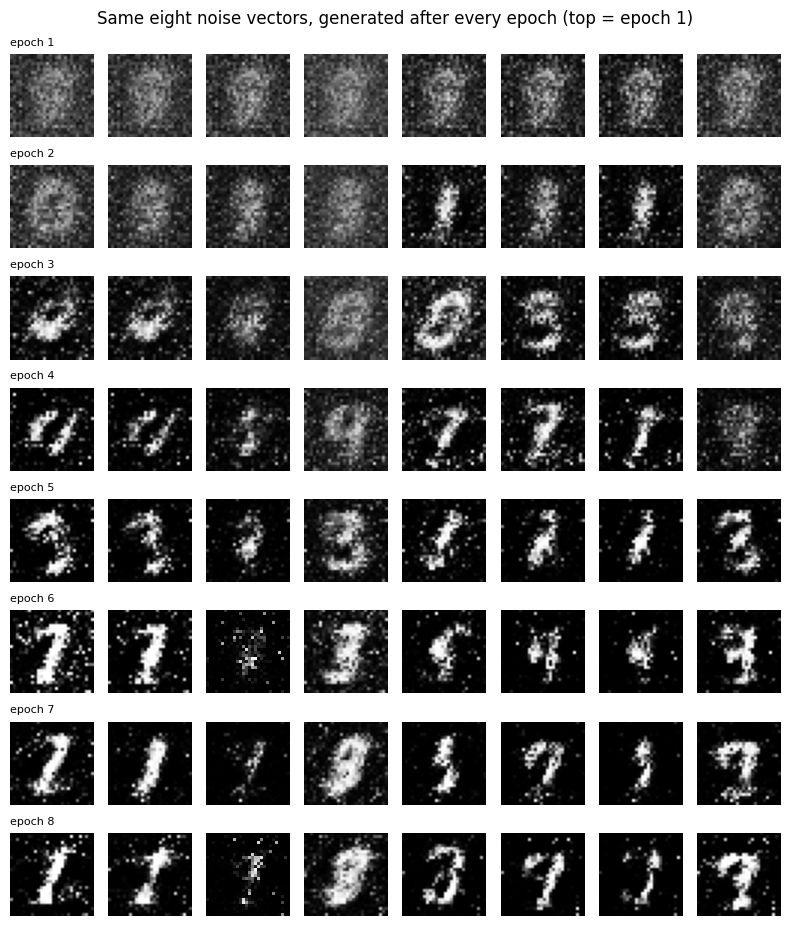

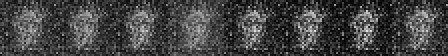

animation above: 8 frames, one per epoch, same noise throughout.


In [3]:
# WHAT/WHY: the four printed lines above are single-batch snapshots of a
# two-player game. Here is the whole game: both losses averaged per epoch, and
# — because a loss curve says nothing about picture quality in a GAN — the same
# eight noise vectors generated after every epoch, as a storyboard and an
# animation. Reuses what training already recorded. The GIF helper is the idiom
# from Course 09's course09_step_viz (frames_to_gif_bytes / display_gif).
import io
import numpy as np
from PIL import Image
from IPython.display import Image as IPyImage, display

ep = [h[0] for h in gan_hist]
dl = [h[1] for h in gan_hist]
gl = [h[2] for h in gan_hist]

print(f"{'epoch':>5} {'D loss':>8} {'G loss':>8}")
for e, d, g in gan_hist:
    print(f"{e:>5} {d:>8.3f} {g:>8.3f}")

fig, ax = plt.subplots(figsize=(6.4, 3.2))
ax.plot(ep, dl, 'o-', label="discriminator loss")
ax.plot(ep, gl, 's-', label="generator loss")
ax.axhline(np.log(4), color='gray', ls=':', lw=1.2,
           label="D loss = 2·ln2 ≈ 1.39 (D guessing at chance)")
ax.set_xlabel("epoch"); ax.set_ylabel("mean loss over the epoch")
ax.set_title("An adversarial game, not an optimisation: neither loss goes to zero")
ax.legend(fontsize=8); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

# ── storyboard: the SAME eight noise vectors, generated after each epoch ──
fig, axes = plt.subplots(len(snapshots), 8, figsize=(8, 1.18 * len(snapshots)))
for r, snap in enumerate(snapshots):
    for c_ in range(8):
        axes[r, c_].imshow(snap[c_], cmap='gray', vmin=-1, vmax=1)
        axes[r, c_].axis('off')
    axes[r, 0].set_title(f"epoch {r+1}", loc='left', fontsize=8)
plt.suptitle("Same eight noise vectors, generated after every epoch (top = epoch 1)")
plt.tight_layout(); plt.show()

# ── and as an animation: one frame per epoch ─────────────────────────────
def frames_to_gif_bytes(frames, duration_ms=520):
    """Encode uint8 frames as one animated GIF (Course 09 course09_step_viz idiom)."""
    imgs = [Image.fromarray(np.asarray(f, dtype=np.uint8)) for f in frames]
    buf = io.BytesIO()
    imgs[0].save(buf, format="GIF", save_all=True, append_images=imgs[1:],
                 duration=duration_ms, loop=0)
    return buf.getvalue()

def display_gif(frames, duration_ms=520):
    display(IPyImage(data=frames_to_gif_bytes(frames, duration_ms), format="gif"))

frames = [np.kron(((np.concatenate(list(s.numpy()), axis=1) + 1) * 127.5).astype(np.uint8),
                  np.ones((2, 2), dtype=np.uint8)) for s in snapshots]
display_gif(frames)
print(f"animation above: {len(frames)} frames, one per epoch, same noise throughout.")


### 👁️ Read the figures

**The loss curves show a game, not a descent.** From epoch 3 on both settle — D holds between 0.62 and 0.70, G between 2.2
and 2.6 — and neither goes near zero. The dotted line marks D loss = 2·ln 2 ≈ 1.39, what
the discriminator would score if it could not tell real from fake at all. Ours sits well below
it, so D is winning comfortably, which is why G's loss is high and stays high. This run is
*stable*, not *balanced*, and no number on this chart tells you whether the pictures are good.

**The storyboard is the actual progress report, and it disagrees with the curves.** The losses
barely move after epoch 3, while the images keep changing a great deal: epoch 1 is eight
near-identical grey ghosts, digits emerge around epochs 4–5, and by epoch 8 they are
recognisable but speckled with stray bright pixels the discriminator never learned to punish.

**Now compare this storyboard with the one in lesson 01.** There, the VAE fixed the map from z
to digit by epoch 2 and spent the rest of training sharpening it. Here the map is rewritten
every epoch: follow any single column down the rows and the digit it decodes to keeps
changing. A VAE optimises against a fixed target — the input image. A GAN's generator chases a
discriminator that moves at every step, so "the same z" has no stable meaning until training
settles. That is the practical face of adversarial training, and the reason you never judge a
GAN by its loss.

## Trying the Real Systems

- **Stable Diffusion**: free on Colab with `diffusers` — see `../../DOCS/COLAB_SETUP.md`; a GPU runtime generates a 512×512 image from your prompt in seconds
- **StyleGAN**: pretrained checkpoints at the official [StyleGAN3 repo](https://github.com/NVlabs/stylegan3); [thispersondoesnotexist.com](https://thispersondoesnotexist.com) shows live output
- **DALL-E**: via the OpenAI API / ChatGPT (paid)


## ⚠️ Where this breaks

**Nothing here runs the three systems**, so nothing here is evidence about their quality. Treat every quality claim in the table as literature you have read, not as a measurement you have made — and say so when you present it.

**The table is a snapshot with a short half-life.** The GAN row has been production-marginal since 2022; the current lineage is latent diffusion with transformer backbones (Peebles & Xie, 2022, arXiv 2212.09748) and flow matching (Lipman et al., 2022, arXiv 2210.02747), and by 2026 understanding and generation are converging into single unified models. Re-derive the table before you brief a client from it.

**"Open weights" is not "open data" and not "unrestricted use".** These are three separate things and they fail separately: the licence governs what you may do with the model, the provenance governs what the model may have absorbed, and Getty v. Stability is about the second. Check both, in writing, before recommending a checkpoint for commercial work.

**The hands-on anchor is an anchor, not a proxy.** It shows you the adversarial mechanism. It tells you nothing about the data curation, distributed training, safety filtering and inference economics that make up most of the engineering in a production generator.


## 🔭 State of the field (2026)

The three systems named in this lesson have been overtaken in two different directions. **Generation
moved to video:** open, documented models now handle text-to-video, image-to-video and video
continuation from a single 13.6B-parameter diffusion transformer (Meituan LongCat Team, 2025, arXiv
2510.22200) — the same latent-diffusion recipe with a temporal axis added. **And understanding and
generation merged:** rather than a separate captioner and a separate generator, 2026 systems
interpret and produce images inside one architecture (Diao et al., 2026, arXiv 2605.12500).
Practically, the open stack a student can actually run in 2026 is a latent-diffusion or
flow-matching transformer with open weights — neither a GAN nor an API-only model.

**Why this lesson is still the right thing to learn.** The skill it teaches is not the three names,
it is the mapping: which family a system belongs to, what it can be steered by, and what hardware,
licence and provenance it demands. The systems cited above are still built from the parts
you assembled in this unit — an autoencoder, a denoiser, and a text conditioner — even where they
rearrange them, so the mapping transfers directly. Do exactly that with it: treat the comparison table above as a worked example,
then rebuild the same table for two 2026 systems before you brief anyone from it.

## 📚 References & Further Reading

**Papers:**
- Karras et al. (2019) — [StyleGAN](https://arxiv.org/abs/1812.04948)
- Ramesh et al. (2022) — [DALL-E 2: Hierarchical Text-Conditional Image Generation](https://arxiv.org/abs/2204.06125)
- Rombach et al. (2022) — [Stable Diffusion: Latent Diffusion Models](https://arxiv.org/abs/2112.10752)
- Goodfellow et al. (2014) — [Generative Adversarial Nets](https://arxiv.org/abs/1406.2661) *(where it all started)*
- Meituan LongCat Team (2025) — [LongCat-Video Technical Report](https://arxiv.org/abs/2510.22200) *(an open 13.6B video generator: text-to-video, image-to-video and video continuation in one model)*
- Diao et al. (2026) — [SenseNova-U1: Unifying Multimodal Understanding and Generation with NEO-unify Architecture](https://arxiv.org/abs/2605.12500) *(understanding and generation in a single architecture)*
- Li et al. (2026) — [Omni-Diffusion: Unified Multimodal Understanding and Generation with Masked Discrete Diffusion](https://arxiv.org/abs/2603.06577) *(the same convergence reached through discrete diffusion, across text, speech and images)*


## 📝 Summary

In **05 — Modern Image Generators** you mapped the three landmark systems onto the architectures you built in this course: StyleGAN = your GAN + style machinery; DALL-E = autoregressive/diffusion generation + text; Stable Diffusion = your example-04 DDPM inside your example-01 VAE latent space + CLIP text conditioning. The comparison table summarizes their trade-offs, and the hands-on anchor re-ran the foundational GAN. Running the production systems needs GPU hardware — the "Trying the Real Systems" section shows the routes.
